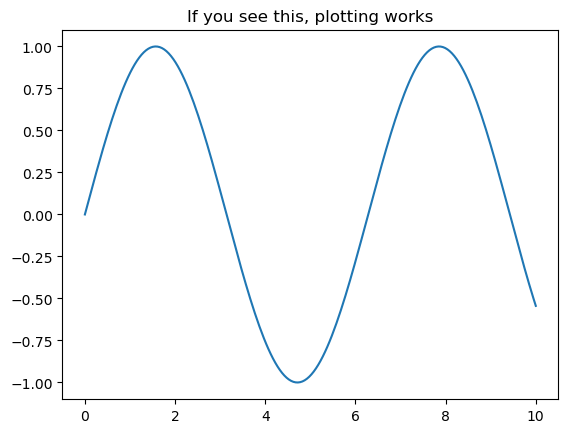

In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

    
# sanity check plot
x = np.linspace(0, 10, 200)
plt.plot(x, np.sin(x))
plt.title("If you see this, plotting works")
plt.show()

# Load the data

In [2]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [3]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [4]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    errors = y-tx @ w
    N = len(y)
    total_loss = np.dot(errors, errors)/2*N
    return total_loss
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************

def compute_loss_mae(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    errors = y-tx @ w
    N = len(y)
    total_loss = np.sum(np.abs(errors))/N
    return total_loss
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************
    
#print(compute_loss(y, tx, np.array([1,2])))

# 2. Grid Search

Fill in the function `grid_search()` below:

In [5]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    for i, w0 in enumerate(grid_w0):
        for j, w1 in enumerate(grid_w1):
            losses[i][j] = compute_loss(y, tx, np.array([w0, w1]))
    return losses
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    # ***************************************************
    raise NotImplementedError
    return losses

Let us play with the grid search demo now!

In [6]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=100)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving
print("tf")

Grid Search: loss*=1555870336.8609498, w0*=72.72727272727272, w1*=13.636363636363626, execution time=0.283 seconds
tf


# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [7]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    N = len(y)
    e = y - tx @ w
    grad = -1/N * np.transpose(tx) @ e
    return grad
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute gradient vector
    # ***************************************************
    raise NotImplementedError
print(compute_gradient(y, tx, np.array([100,20])))
print(compute_gradient(y, tx, np.array([50,10])))

[26.706078    6.52028757]
[-23.293922    -3.47971243]


Please fill in the functions `gradient_descent` below:

In [8]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute gradient and loss
        # ***************************************************
        loss = compute_loss(y, tx, w)
        grad = compute_gradient(y, tx, w)
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by gradient
        # ***************************************************
        w = w + gamma*-grad
        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [9]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.53858878now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
print("Intial gradient: ", compute_gradient(y, tx, w_initial))
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=279223671275.9167, w0=7.329392200210518, w1=1.3479712434989277
GD iter. 1/49: loss=226463505603.0002, w0=13.925845180399984, w1=2.56114536264797
GD iter. 2/49: loss=183727771407.93793, w0=19.862652862570506, w1=3.6530020698821017
GD iter. 3/49: loss=149111826709.93738, w0=25.20577977652398, w1=4.635673106392817
GD iter. 4/49: loss=121072911504.55696, w0=30.014593999082102, w1=5.520077039252463
GD iter. 5/49: loss=98361390188.19885, w0=34.3425267993844, w1=6.3160405788261365
GD iter. 6/49: loss=79965057921.94882, w0=38.237666319656476, w1=7.032407764442442
GD iter. 7/49: loss=65064028786.286285, w0=41.74329188790134, w1=7.677138231497114
GD iter. 8/49: loss=52994195186.39964, w0=44.898354899321724, w1=8.257395651846316
GD iter. 9/49: loss=43217629970.491455, w0=47.73791160960006, w1=8.779627330160597
GD iter. 10/49: loss=35298612145.60584, w0=50.29351264885057, w1=9.249635840643451
GD iter. 11/49: loss=28884207707.44847, w0=52.59355358417603, w1=9.672643500078017
GD 

In [10]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

In [11]:
#Testing batch iter
b = batch_iter(y, tx, 2, 3)
next(b)
by, btx = next(b)
print(btx)


[[1.         0.53369724]
 [1.         0.333989  ]]


# 4. Stochastic gradient descent

In [12]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """
    #return compute_gradient(y, tx, w)
    # Do we really need this?
    
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    # ***************************************************
    raise NotImplementedError


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w


    batcher = batch_iter(y, tx, batch_size, max_iters)

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic gradient descent.
        # ***************************************************

        by, btx = next(batcher)
        loss = compute_loss(y, tx, w)
        grad = compute_gradient(by, btx, w)
        w = w + gamma*-grad

        # store w and loss
        ws.append(w)
        losses.append(loss)

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [13]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=279223671275.9167, w0=8.736234188351942, w1=5.770792482656145
SGD iter. 1/49: loss=212894713921.35776, w0=13.860962816629781, w1=-0.06789114210451164
SGD iter. 2/49: loss=187329298798.10602, w0=16.95407470450716, w1=-4.580589705423627
SGD iter. 3/49: loss=176556234132.8659, w0=19.679545849215565, w1=-8.760944883713854
SGD iter. 4/49: loss=169995997198.45868, w0=23.626740366909967, w1=-10.418502852286043
SGD iter. 5/49: loss=153436270061.90414, w0=28.41441230455827, w1=-11.167243114651315
SGD iter. 6/49: loss=132620729214.79083, w0=39.31142819006149, w1=12.163161612428377
SGD iter. 7/49: loss=59365748374.58141, w0=42.72882476386757, w1=15.015047930885126
SGD iter. 8/49: loss=48367710000.276695, w0=46.21358818790763, w1=16.404452474790563
SGD iter. 9/49: loss=38633517976.322235, w0=49.316706661554704, w1=13.855125293814922
SGD iter. 10/49: loss=30290978301.967857, w0=52.811036661722646, w1=11.903081114220786
SGD iter. 11/49: loss=22640306696.327106, w0=55.72528880528

In [14]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 5. Effect of Outliers and MAE Cost Function

In [15]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: reload the data by subsampling first, then by subsampling and adding outliers
# ***************************************************
raise NotImplementedError

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

NotImplementedError: 

In [ ]:
y.shape, tx.shape

In [16]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])
height, weight, gender = load_data(sub_sample=True, add_outlier=True)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: fit the model to the subsampled data / subsampled data with outliers and visualize the cloud of points
#       and the model fit
# ***************************************************
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)


end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=117100752.01352093, w0=51.847464098448434, w1=7.724426406192428
GD iter. 1/49: loss=12987183.816323929, w0=67.40170332798299, w1=10.041754328050118
GD iter. 2/49: loss=3616962.678576185, w0=72.06797509684336, w1=10.736952704607411
GD iter. 3/49: loss=2773642.7761788876, w0=73.46785662750146, w1=10.945512217574596
GD iter. 4/49: loss=2697743.984963131, w0=73.88782108669889, w1=11.00808007146475
GD iter. 5/49: loss=2690913.0937537136, w0=74.01381042445813, w1=11.026850427631796
GD iter. 6/49: loss=2690298.3135448657, w0=74.0516072257859, w1=11.03248153448191
GD iter. 7/49: loss=2690242.98332607, w0=74.06294626618423, w1=11.034170866536943
GD iter. 8/49: loss=2690238.0036063776, w0=74.06634797830372, w1=11.034677666153454
GD iter. 9/49: loss=2690237.5554316053, w0=74.06736849193958, w1=11.034829706038407
GD iter. 10/49: loss=2690237.515095876, w0=74.06767464603033, w1=11.034875318003893
GD iter. 11/49: loss=2690237.5114656603, w0=74.06776649225755, w1=11.03488900159354

In [17]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 6. Subgradient descent

In [18]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute subgradient gradient vector for MAE
    # ***************************************************
    N = len(y)
    e = y - tx @ w
    print(np.sum(np.sign(e) == 0))
    grad = -1/N * np.transpose(tx) @ np.sign(e)
    return grad

In [19]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        
        loss = compute_loss_mae(y, tx, w)
        grad = compute_subgradient_mae(y, tx, w)
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by subgradient
        # ***************************************************
        w = w + gamma*-grad
        # store w and loss

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [20]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

0
SubGD iter. 0/499: loss=74.06780585492638, w0=0.7000000000000004, w1=7.237266341775239e-16
0
SubGD iter. 1/499: loss=73.36780585492637, w0=1.4000000000000008, w1=1.4474532683550478e-15
0
SubGD iter. 2/499: loss=72.66780585492637, w0=2.1000000000000014, w1=2.1711799025325716e-15
0
SubGD iter. 3/499: loss=71.96780585492637, w0=2.8000000000000016, w1=2.8949065367100956e-15
0
SubGD iter. 4/499: loss=71.26780585492638, w0=3.5000000000000018, w1=3.6186331708876196e-15
0
SubGD iter. 5/499: loss=70.56780585492638, w0=4.200000000000002, w1=4.342359805065143e-15
0
SubGD iter. 6/499: loss=69.86780585492637, w0=4.900000000000002, w1=5.066086439242667e-15
0
SubGD iter. 7/499: loss=69.16780585492637, w0=5.600000000000002, w1=5.7898130734201904e-15
0
SubGD iter. 8/499: loss=68.46780585492637, w0=6.3000000000000025, w1=6.513539707597714e-15
0
SubGD iter. 9/499: loss=67.76780585492638, w0=7.000000000000003, w1=7.237266341775238e-15
0
SubGD iter. 10/499: loss=67.06780585492638, w0=7.700000000000003, w

In [21]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [22]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    batcher = batch_iter(y, tx, batch_size, max_iters)


    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic subgradient descent.
        # ***************************************************
        by, btx = next(batcher)
        loss = compute_loss_mae(y, tx, w)
        stoch_sub_gradient = compute_subgradient_mae(by, btx, w)
        w = w + gamma*-stoch_sub_gradient

        ws.append(w)
        losses.append(loss)

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [23]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

0
SubSGD iter. 0/499: loss=74.06780585492638, w0=0.7, w1=-0.9435064835371203
0
SubSGD iter. 1/499: loss=73.36780585492637, w0=1.4, w1=-1.5645580571077138
0
SubSGD iter. 2/499: loss=72.66780585492639, w0=2.0999999999999996, w1=-1.30384583572585
0
SubSGD iter. 3/499: loss=71.96780585492638, w0=2.8, w1=-0.6609161369620544
0
SubSGD iter. 4/499: loss=71.26780585492638, w0=3.5, w1=-0.282376353605323
0
SubSGD iter. 5/499: loss=70.56780585492638, w0=4.2, w1=0.8859544469121456
0
SubSGD iter. 6/499: loss=69.86780585492637, w0=4.9, w1=0.18244952852128304
0
SubSGD iter. 7/499: loss=69.16780585492639, w0=5.6000000000000005, w1=0.16387006962240644
0
SubSGD iter. 8/499: loss=68.46780585492638, w0=6.300000000000001, w1=-0.4060900549135794
0
SubSGD iter. 9/499: loss=67.76780585492638, w0=7.000000000000001, w1=-0.9601971289101602
0
SubSGD iter. 10/499: loss=67.06780585492638, w0=7.700000000000001, w1=-1.0604742281503696
0
SubSGD iter. 11/499: loss=66.36780585492639, w0=8.4, w1=-0.9281507017965309
0
SubS

## from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))